In [1]:
# ============================================================
# Rising Waters: A Machine Learning Approach to Flood Prediction
# Epic 2 - Story 1 : Import Required Libraries
# ============================================================

# Numerical Computation
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Epic 2 - Story 2 : Load the Flood Prediction Dataset
# ============================================================

dataset = pd.read_excel("../flood dataset.xlsx")

In [3]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [4]:
dataset.shape

(115, 11)

In [5]:
dataset.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [7]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


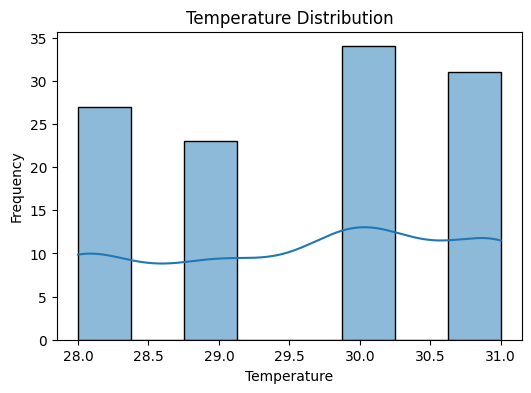

In [8]:
# ============================================================
# Epic 2 - Story 3 : Univariate Analysis
# Distribution Plot - Temperature
# ============================================================

plt.figure(figsize=(6,4))

sns.histplot(dataset["Temp"], kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

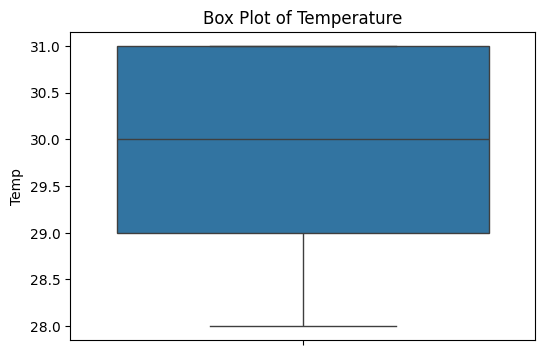

In [9]:
plt.figure(figsize=(6,4))

sns.boxplot(y=dataset["Temp"])

plt.title("Box Plot of Temperature")

plt.show()

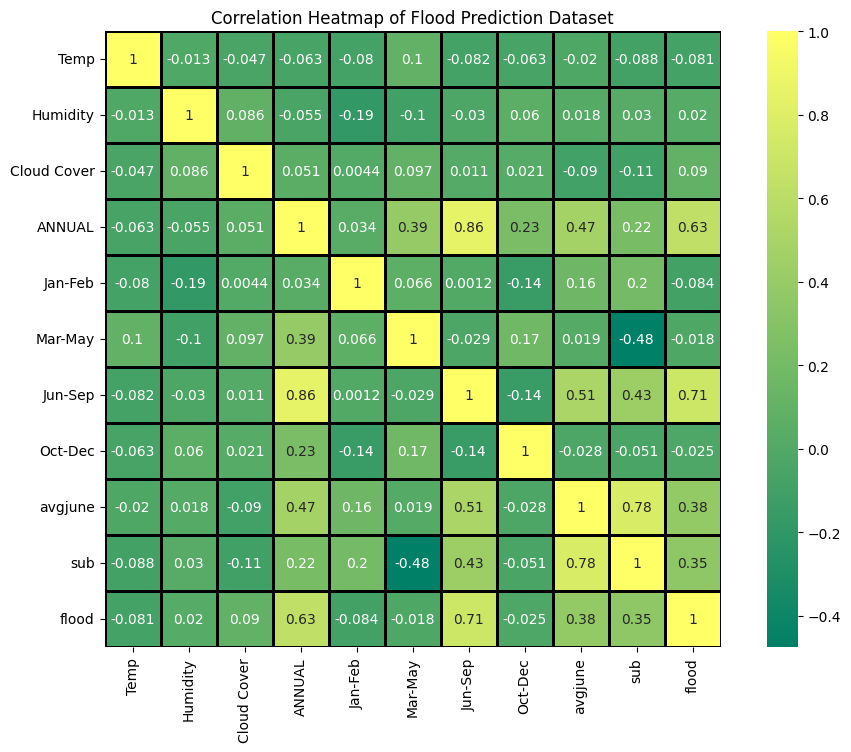

In [10]:
# ============================================================
# Epic 2 - Story 4 : Multivariate Analysis
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="summer",
    linewidths=1,
    linecolor="black",
    square=True
)

plt.title("Correlation Heatmap of Flood Prediction Dataset")
plt.show()

In [11]:
# ============================================================
# Epic 2 - Story 5 : Descriptive Analysis
# Display First Five Records
# ============================================================

dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [12]:
dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

In [21]:
# ============================================================
# Epic 3 - Story 4 : Split Dataset into Features and Target
# ============================================================

# Independent Features
X = dataset.iloc[:, 2:7].values

# Target Variable
y = dataset.iloc[:, 10].values

In [22]:
# ============================================================
# Epic 3 - Story 5 : Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=10
)

In [23]:
# ============================================================
# Epic 3 - Story 6 : Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
# ============================================================
# Epic 4 - Story 1 : Import Machine Learning Algorithms
# ============================================================

from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost

In [25]:
# ============================================================
# Epic 4 - Story 2 : Create Model Objects
# ============================================================

dtree = tree.DecisionTreeClassifier()

rf = ensemble.RandomForestClassifier()

knn = neighbors.KNeighborsClassifier()

xgb = xgboost.XGBClassifier()

In [26]:
# ============================================================
# Epic 4 - Story 3 : Train the Machine Learning Models
# ============================================================

dtree.fit(X_train, y_train)

rf.fit(X_train, y_train)

knn.fit(X_train, y_train)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
# ============================================================
# Epic 4 - Story 4 : Generate Predictions
# ============================================================

p1 = dtree.predict(X_test)
p2 = rf.predict(X_test)
p3 = knn.predict(X_test)
p4 = xgb.predict(X_test)

In [28]:
from sklearn import metrics

print("Decision Tree Accuracy :", metrics.accuracy_score(y_test, p1))
print("Random Forest Accuracy :", metrics.accuracy_score(y_test, p2))
print("KNN Accuracy           :", metrics.accuracy_score(y_test, p3))
print("XGBoost Accuracy       :", metrics.accuracy_score(y_test, p4))

Decision Tree Accuracy : 0.9655172413793104
Random Forest Accuracy : 0.9655172413793104
KNN Accuracy           : 0.896551724137931
XGBoost Accuracy       : 0.9655172413793104


In [29]:
print("Accuracy :", metrics.accuracy_score(y_test, p4))
print("Confusion Matrix:")
print(metrics.confusion_matrix(y_test, p4))

print("Classification Report:")
print(metrics.classification_report(y_test, p4))

Accuracy : 0.9655172413793104
Confusion Matrix:
[[26  0]
 [ 1  2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [30]:
dtree.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
from sklearn import metrics

print(metrics.accuracy_score(y_test, p1))
print(metrics.accuracy_score(y_test, p2))
print(metrics.accuracy_score(y_test, p3))
print(metrics.accuracy_score(y_test, p4))

0.9655172413793104
0.9655172413793104
0.896551724137931
0.9655172413793104


In [32]:
print(metrics.confusion_matrix(y_test, p4))

[[26  0]
 [ 1  2]]


In [33]:
print(metrics.classification_report(y_test, p4))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def xgboost_model(X_train, X_test, y_train, y_test):

    print("\n========== XGBOOST MODEL BUILDING ==========")

    # Initialize XGBoost Classifier
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )

    # Train the model
    model.fit(X_train, y_train)
    print("[INFO] XGBoost model training completed.")

    # Predict
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed.")

    # Evaluate
    print("\nAccuracy :", accuracy_score(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return model, y_pred

In [35]:
xgb_model, p4 = xgboost_model(
    X_train,
    X_test,
    y_train,
    y_test
)


========== XGBOOST MODEL BUILDING ==========
[INFO] XGBoost model training completed.
[INFO] Prediction completed.

Accuracy : 0.9655172413793104

Confusion Matrix:
[[26  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [36]:
from sklearn import metrics

print("Decision Tree Accuracy :", metrics.accuracy_score(y_test, p1))
print("Random Forest Accuracy :", metrics.accuracy_score(y_test, p2))
print("KNN Accuracy           :", metrics.accuracy_score(y_test, p3))
print("XGBoost Accuracy       :", metrics.accuracy_score(y_test, p4))

Decision Tree Accuracy : 0.9655172413793104
Random Forest Accuracy : 0.9655172413793104
KNN Accuracy           : 0.896551724137931
XGBoost Accuracy       : 0.9655172413793104


In [37]:
print("Accuracy :", metrics.accuracy_score(y_test, p4))

Accuracy : 0.9655172413793104


In [38]:
print(metrics.confusion_matrix(y_test, p4))

[[26  0]
 [ 1  2]]


In [39]:
print(metrics.precision_score(y_test, p4))

1.0


In [40]:
print(metrics.classification_report(y_test, p4))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [41]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [42]:
import joblib

In [43]:
joblib.dump(xgb, "../models/floods.save")

['floods.save']

In [44]:
sc = StandardScaler()

In [45]:
X_train = sc.fit_transform(X_train)

In [46]:
joblib.dump(sc, "../models/transform.save")

['transform.save']

In [47]:
import joblib

model = joblib.load("../models/floods.save")
scaler = joblib.load("../models/transform.save")

print("Model Loaded Successfully")
print("Scaler Loaded Successfully")

Model Loaded Successfully
Scaler Loaded Successfully


In [49]:
import os

print(os.getcwd())

C:\Users\nanda


In [50]:
import joblib

joblib.dump(xgb, "../models/floods.save")
joblib.dump(sc, "../models/transform.save")

['transform.save']